---
title: Estimating space- and time-varying transmission rate from data
jupyter: python3
---

::: {.callout-warning}
Epymorph's Bayesian filtering functionality is currently in beta and subject to change. 
:::

### Scenario

It is common that we want to account for and quanitfy heterogeneity in transmission rates among localities to better understand the regional picture of pathogen spread. Therefore, we may have a spatial model with multiple nodes, and we want to understand from data how the transmission rate varies among localities. We may also want to quantify this spatial heterogeneity while also accounting for host movement among localities. In `epymorph`, we have built convenient parameter estimation functionality that allows us to estimate location- and time-varying parameters. In this scenario, we will explore how to set up the model and particle filter simulation for a multi-node system. 


# Exercise 1

First, we will develop a multi-node simulation that does not include the effects of movement.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from epymorph.kit import *
from epymorph.adrio import acs5

from epymorph.adrio import us_tiger

from epymorph.forecasting.pipeline import (
    PipelineConfig,
    ParticleFilterSimulator,
    Observations,
    ModelLink,
    UnknownParam,
)

from epymorph.forecasting.likelihood import PoissonLikelihood
from epymorph.forecasting.dynamic_params import BrownianMotion
from epymorph.forecasting.dynamic_params import GaussianPrior, ExponentialTransform

from epymorph.adrio.cdc import (
    InfluenzaStateHospitalization,
    InfluenzaStateHospitalizationDaily,
)
from epymorph.time import EveryNDays

from epymorph.initializer import RandomLocationsAndRandomSeed

- [ ] Import the initializer `RandomLocationsAndRandomSeed`. This initializer draws the initial infected uniformly on `[0,seed_max]` and utilizes a multivariate hypergeometric draw to distribute infected to a number of locations. 

- [ ] Construct a RUME with a scope consisting of four States, but assume that there is no movement between the states. Essentially, this simulates four independent populations. Use an SIRH IPM. In each State, initialize a small fraction initially infectious.

In [2]:
states = ["AZ", "CO", "NM", "NV"]
rume = SingleStrataRUME.build(
    ipm=ipm.SIRH(),
    mm=mm.No(),
    scope=StateScope.in_states(states, year=2015),
    init=RandomLocationsAndRandomSeed(num_locations=len(states), seed_max=10_000),
    time_frame=TimeFrame.of("2022-09-15", 7 * 26 + 1),
    params={
        "beta": ExponentialTransform("log_beta"),
        "gamma": 0.2,
        "xi": 1 / 365,
        "hospitalization_prob": 200 / 100_000,
        "hospitalization_duration": 5.0,
        "population": acs5.Population(),
        "centroid": us_tiger.InternalPoint(),
    },
)

- [ ] Construct the Observations object. This describes the observations we would like to fit to using particle filter. We utilize the `InfluenzaStateHospitalization` ADRIO for data, which gives the sum of new hospitalizations over a weekly period. 

In [3]:
observations = Observations(
    source=InfluenzaStateHospitalization(),
    model_link=ModelLink(
        quantity=rume.ipm.select.events("I->H"),
        time=rume.time_frame.select.all().group(EveryNDays(7)).agg(),
        geo=rume.scope.select.all(),
    ),
    likelihood=PoissonLikelihood(),
)

- [ ] Define the unknown parameters and their dynamics. The prior describes the probability distribution we draw from to initialize the parameter for each particle. The dynamics describe how the parameter evolves in time. 

In [ ]:
unknown_params = {
    "log_beta": UnknownParam(
        prior=GaussianPrior(mean=np.log(0.2), standard_deviation=0.5),
        dynamics=BrownianMotion(volatility=0.1),
    )
}

- [ ] Define the particle filter object. num_realizations is the number of particles to use in the algorithm run.

In [5]:
num_realizations = 100

particle_filter_simulator = ParticleFilterSimulator(
    config=PipelineConfig.from_rume(
        rume, num_realizations, unknown_params=unknown_params
    ),
    observations=observations,
)

In [6]:
rng = np.random.default_rng(0)
particle_filter_output = particle_filter_simulator.run(rng=rng)

Observation: 0, Label: 2022-09-15, Time Frame: 2022-09-15/2022-09-21 (7D)
Observation: 1, Label: 2022-09-22, Time Frame: 2022-09-22/2022-09-28 (7D)
Observation: 2, Label: 2022-09-29, Time Frame: 2022-09-29/2022-10-05 (7D)
Observation: 3, Label: 2022-10-06, Time Frame: 2022-10-06/2022-10-12 (7D)
Observation: 4, Label: 2022-10-13, Time Frame: 2022-10-13/2022-10-19 (7D)
Observation: 5, Label: 2022-10-20, Time Frame: 2022-10-20/2022-10-26 (7D)
Observation: 6, Label: 2022-10-27, Time Frame: 2022-10-27/2022-11-02 (7D)
Observation: 7, Label: 2022-11-03, Time Frame: 2022-11-03/2022-11-09 (7D)
Observation: 8, Label: 2022-11-10, Time Frame: 2022-11-10/2022-11-16 (7D)
Observation: 9, Label: 2022-11-17, Time Frame: 2022-11-17/2022-11-23 (7D)
Observation: 10, Label: 2022-11-24, Time Frame: 2022-11-24/2022-11-30 (7D)
Observation: 11, Label: 2022-12-01, Time Frame: 2022-12-01/2022-12-07 (7D)
Observation: 12, Label: 2022-12-08, Time Frame: 2022-12-08/2022-12-14 (7D)
Observation: 13, Label: 2022-12-15,

- [ ] Plot the output of the particle filtering algorithm against the real data. 

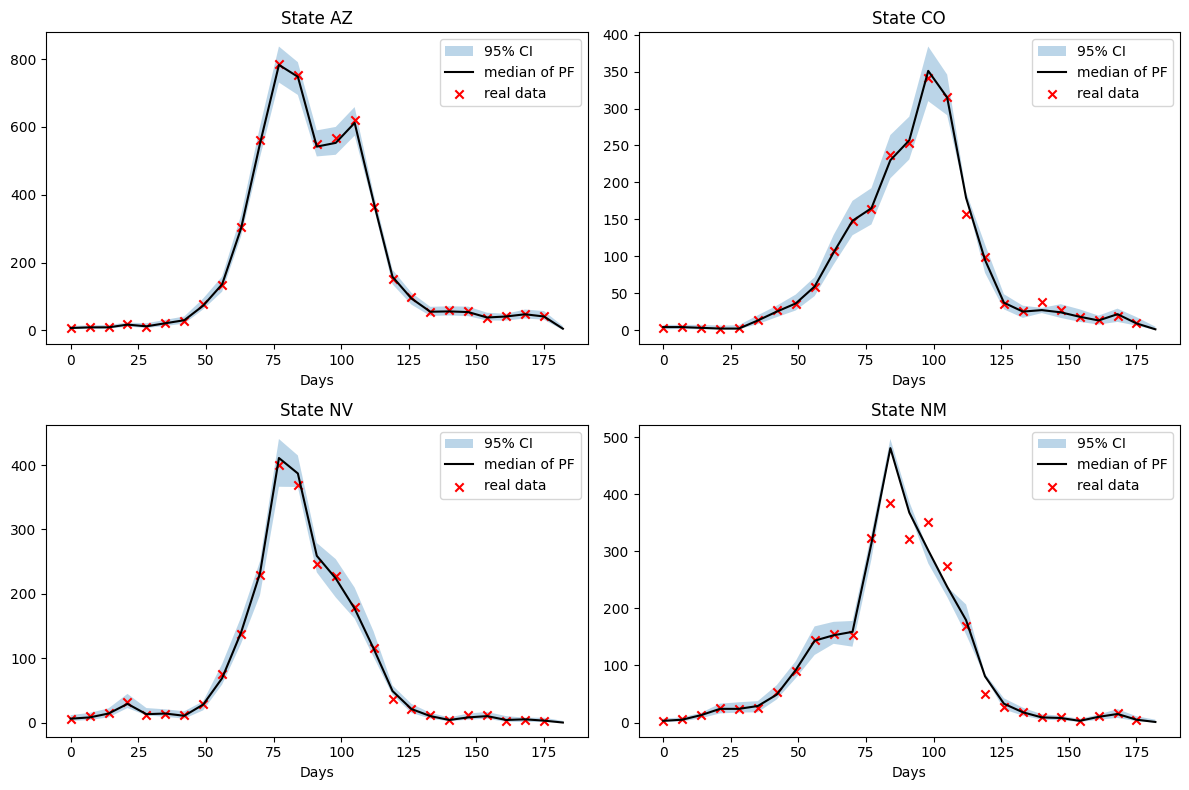

In [7]:
#| eval: false

from epymorph.attribute import NamePattern
from math import ceil

real_data_result = observations.source.with_context(scope = rume.scope,time_frame = rume.time_frame).inspect().result
real_data = real_data_result["value"]

data_date_range = np.arange(0, rume.time_frame.days, 7)
sim_date_range = np.arange(0, rume.time_frame.days, 1)

n = len(rume.scope.labels)
cols = 2
rows = ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i in range(n):
    ax = axes[i]
    ax.set_title(f"State {rume.scope.labels[i]}")
    ax.set_xlabel("Days")

    lower = np.percentile(
        particle_filter_output.posterior_values[:, :, i], 2.5, axis=0
    ).squeeze()
    upper = np.percentile(
        particle_filter_output.posterior_values[:, :, i], 97.5, axis=0
    ).squeeze()
    mean = np.median(particle_filter_output.posterior_values[:, :, i], axis=0).squeeze()

    ax.fill_between(data_date_range, lower, upper, label="95% CI", alpha=0.3)
    ax.plot(data_date_range, mean, color="black", label="median of PF")

    ax.scatter(
        data_date_range[:-1],
        real_data[:, i],
        marker="x",
        color="red",
        label="real data",
    )
    ax.legend()

for j in range(i + 1, rows * cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

fig.tight_layout()

![](img/G3-pf/fit_of_data.png)

We see a strong fit to the data for three of the states, Nevada has difficulty fitting the model with the data between day 75 and 100. The 95% credible interval describes the interval within which 95% of the particles fall. 

- [ ] Plot the inferred value of $\beta$ for each location over time.

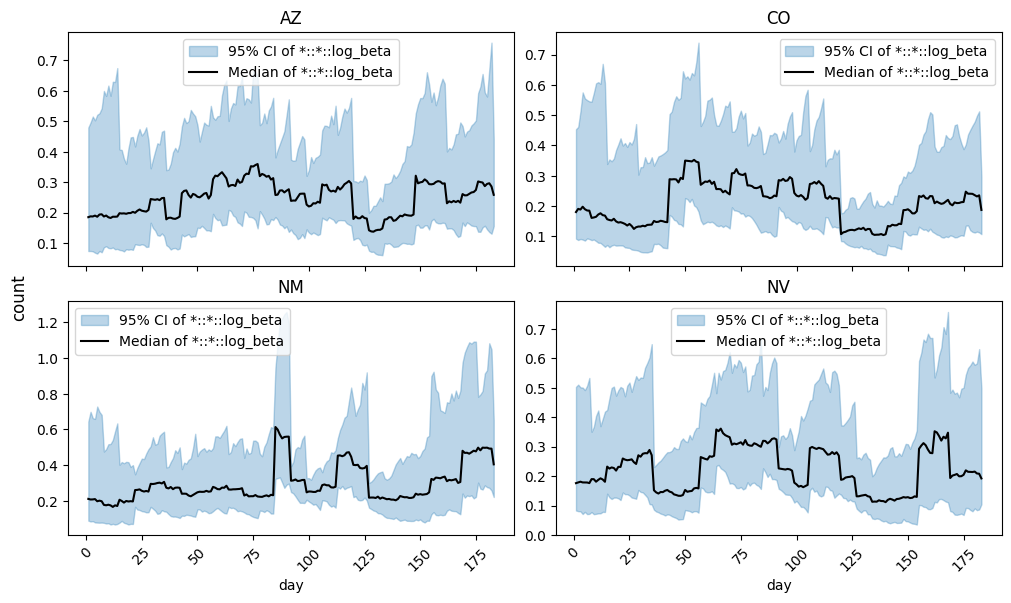

In [8]:
from epymorph.forecasting.filter_plot import PlotRendererPipeline
from math import exp

plotter = PlotRendererPipeline(particle_filter_output)
geo = rume.scope.select.all()
time = rume.time_frame.select.all()

def exp_transform(data_df):
    exp_value = data_df["value"].apply(lambda x: exp(x))
    return data_df.assign(value=exp_value)

quantity = particle_filter_output.param_select.by_name('log_beta')
plotter.quantiles(
        geo,
        time,
        quantity,
        ncols = 2,
        line_kwargs=[{"color": "black"}],
        fill_kwargs=[{"color": "tab:blue", "alpha": 0.3}],
        credible_intervals=[95],
        transform = exp_transform
    )

![](img/G3-pf/fit_of_beta.png)

 We see a relatively stationary value of $\beta$ for each location. While seasonal osciallations can be expected in $\beta$ for certain diseases, agressive and non-smooth oscillations are often indicative of model error.

- [ ] Plot the inferred compartment values for $S,I,R,H$ from the particle filter run. 

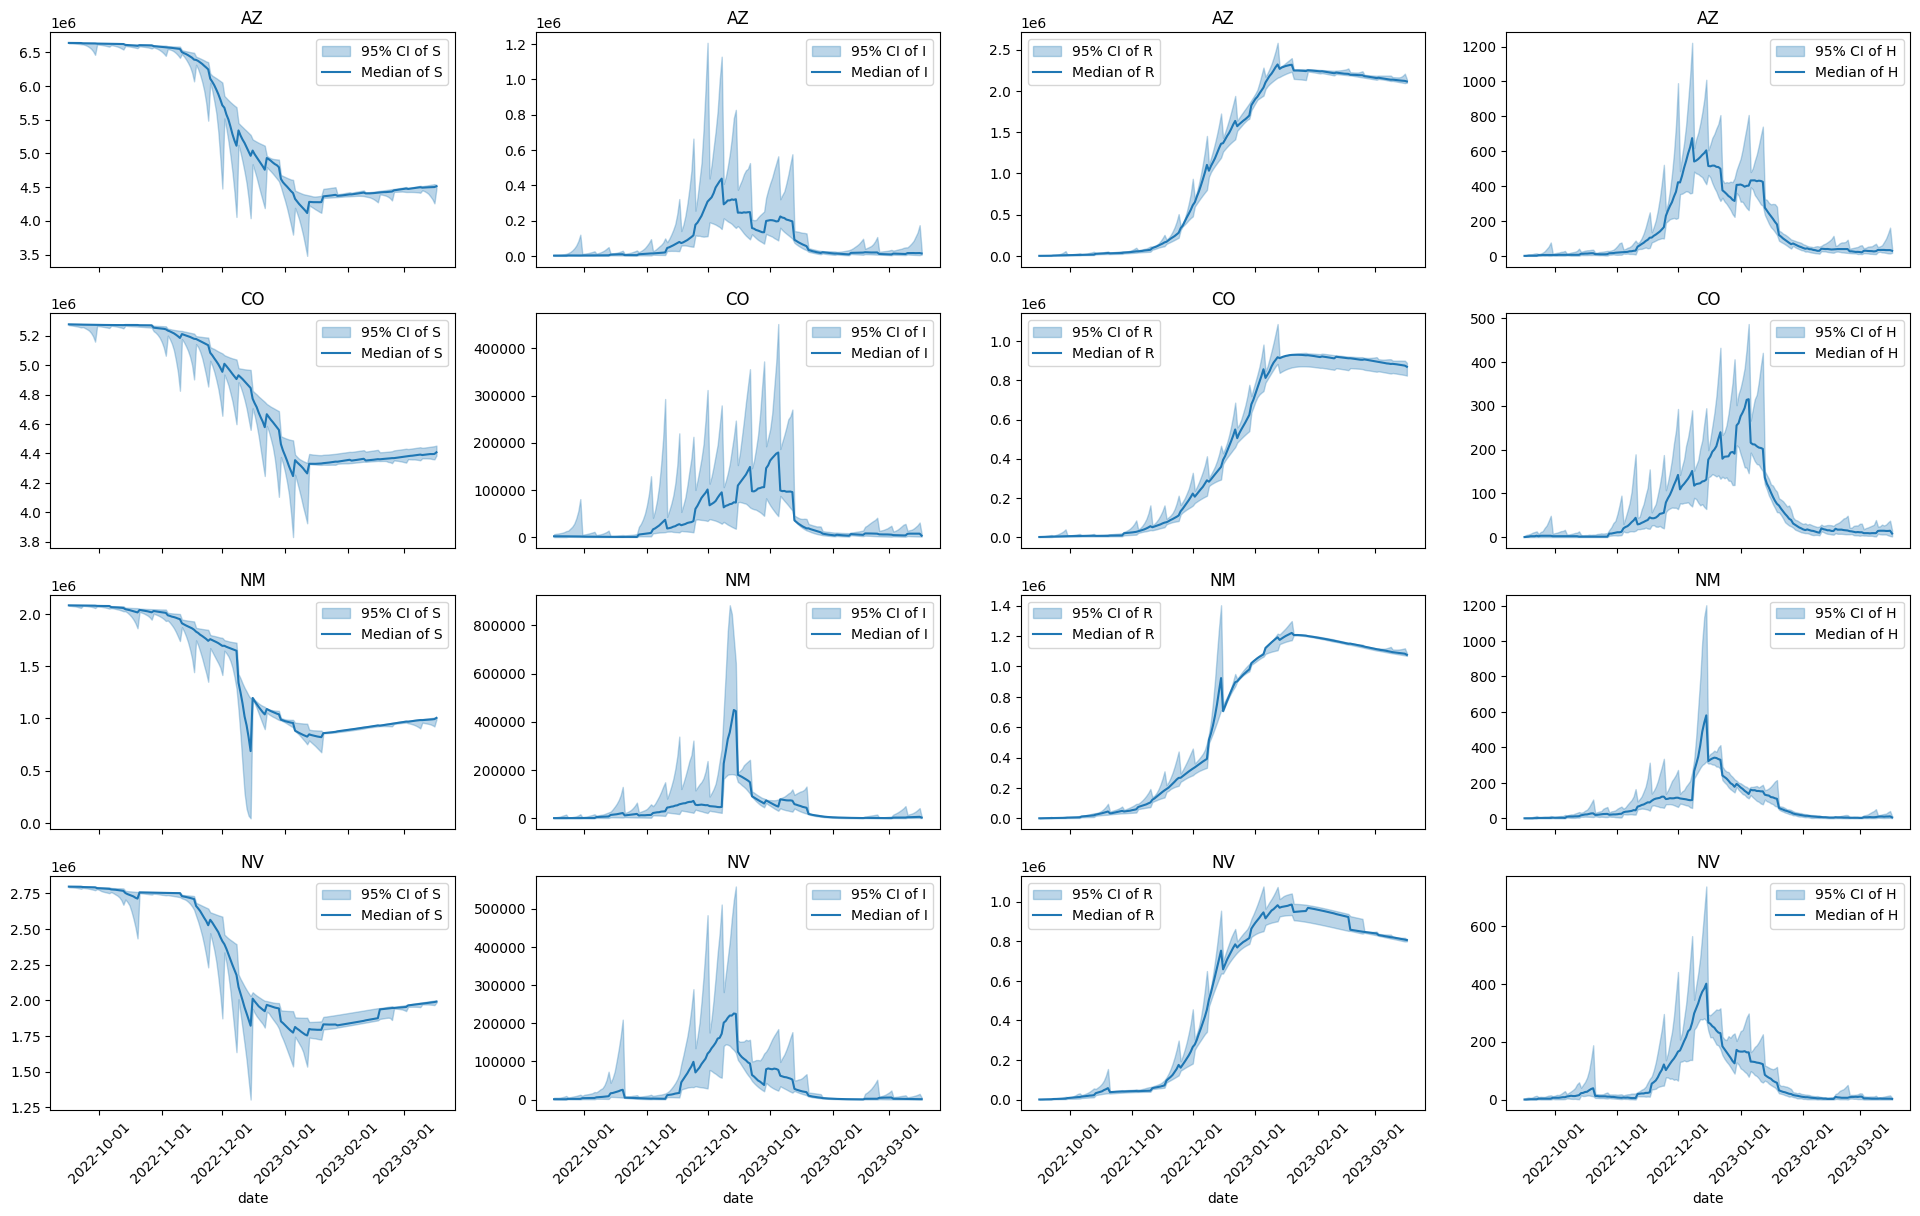

In [9]:
a = particle_filter_output.compartments.shape[3]
compartment_labels = ["S", "I", "R", "H"]

rows = n
cols = a

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.5 * rows), sharex=True)

plotter = PlotRendererPipeline(particle_filter_output)
geo = rume.scope.select.all()
time = rume.time_frame.select.all()

for col in range(cols):
    col_axes = axes[:, col]

    quantity = rume.ipm.select.compartments(compartment_labels[col])

    plotter.quantiles_plt(
        col_axes,
        geo,
        time,
        quantity,
        line_kwargs=[{"color": "tab:blue"}],
        fill_kwargs=[{"color": "tab:blue", "alpha": 0.3}],
        credible_intervals=[95],
        legend="on",
        time_format="date"
    )

plt.show()

![](img/G3-pf/fit_of_compartments.png)

## Notes 

As in the single node example we observe a strong sawtooth effect due to the sparsity of the data. Posterior distributions adjust sharply each week when new data becomes available. In this example the issue is compounded due to model error. Model error is the discrepancy between the real epidemiological processes that generated the data and the prescribed model. As our SIRH model is a significant approximation of the complex processes underlying influenza spread, the model error is non-trivial. 

# Exercise 2

The following will fit the same model as above using a daily data source. From August 1st, 2020 to April 30th, 2024 the CDC required hospitals report data on new admissions and total hospitalizations daily. The facility level daily hospitalization data is not available for privacy reasons, however the state aggregations are. We can then fit our model using daily observations of the new hospitalizations and compare the fit to the weekly data. 

- [ ] Construct an ADRIO to sample the daily data source. We utilize the epymorph ADRIO `InfluenzaStateHospitalizationDaily` with column `admissions`. 

- [ ] Now we construct a new Observations object. We need to change the aggregation of the data as well as the likelihood function. The daily data tends to be overdispersed and a Negative Binomial likelihood function is therefore more appropriate. The parameter r controls the overdispersion of the observations. As r increases the Negative Binomial distribution approximates the Poisson distribution. 

In [10]:
from epymorph.forecasting.likelihood import NegativeBinomialLikelihood

adrio_daily = InfluenzaStateHospitalizationDaily(column="admissions")

observations_daily = Observations(
    source=adrio_daily,
    model_link=ModelLink(
        quantity=rume.ipm.select.events("I->H"),
        time=rume.time_frame.select.all()
        .group(EveryNDays(1))
        .agg(),  # Changed from 1 day to 7 days
        geo=rume.scope.select.all(),
    ),
    likelihood=NegativeBinomialLikelihood(r=10),  # Changed to a negative binomial likelihood
)

We now setup a new particle filter simulator with the updated observations and likelihood. 

In [11]:
particle_filter_simulator_daily = ParticleFilterSimulator(
    config=PipelineConfig.from_rume(
        rume, num_realizations, unknown_params=unknown_params
    ),
    observations=observations_daily,
)

In [12]:
particle_filter_output_daily = particle_filter_simulator_daily.run(rng=rng)

Observation: 0, Label: 2022-09-15, Time Frame: 2022-09-15 (1D)
Observation: 1, Label: 2022-09-16, Time Frame: 2022-09-16 (1D)
Observation: 2, Label: 2022-09-17, Time Frame: 2022-09-17 (1D)
Observation: 3, Label: 2022-09-18, Time Frame: 2022-09-18 (1D)
Observation: 4, Label: 2022-09-19, Time Frame: 2022-09-19 (1D)
Observation: 5, Label: 2022-09-20, Time Frame: 2022-09-20 (1D)
Observation: 6, Label: 2022-09-21, Time Frame: 2022-09-21 (1D)
Observation: 7, Label: 2022-09-22, Time Frame: 2022-09-22 (1D)
Observation: 8, Label: 2022-09-23, Time Frame: 2022-09-23 (1D)
Observation: 9, Label: 2022-09-24, Time Frame: 2022-09-24 (1D)
Observation: 10, Label: 2022-09-25, Time Frame: 2022-09-25 (1D)
Observation: 11, Label: 2022-09-26, Time Frame: 2022-09-26 (1D)
Observation: 12, Label: 2022-09-27, Time Frame: 2022-09-27 (1D)
Observation: 13, Label: 2022-09-28, Time Frame: 2022-09-28 (1D)
Observation: 14, Label: 2022-09-29, Time Frame: 2022-09-29 (1D)
Observation: 15, Label: 2022-09-30, Time Frame: 20

- [ ] Plot the particle filter output. Here we plot the data fit for each of the four locations. 

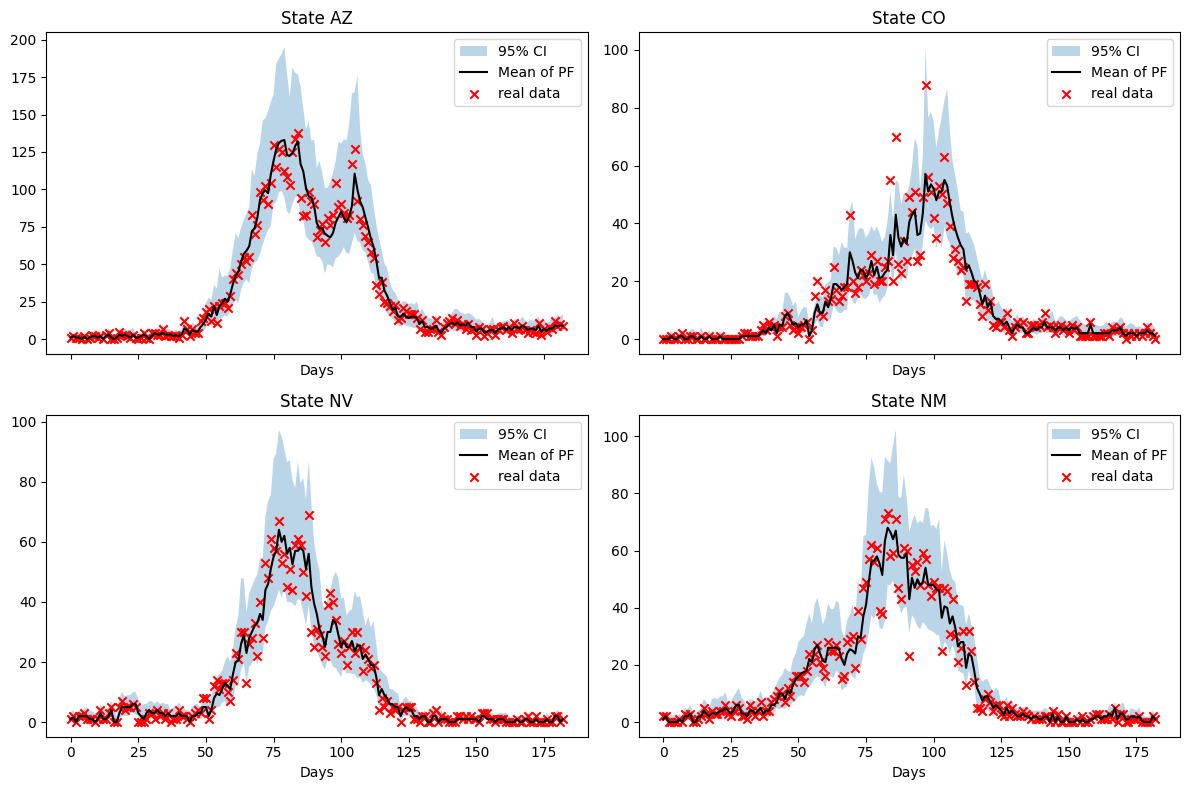

In [13]:
#| eval: false

real_data_result = (
    observations_daily.source.with_context(scope = rume.scope,time_frame = rume.time_frame).inspect().result
)

real_data = real_data_result["value"]

data_date_range = np.arange(0, rume.time_frame.days, 1)
sim_date_range = np.arange(0, rume.time_frame.days, 1)

n = len(rume.scope.labels)
cols = 2
rows = ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), sharex=True)
axes = axes.flatten()

for i in range(n):
    ax = axes[i]
    ax.set_title(f"State {rume.scope.labels[i]}")
    ax.set_xlabel("Days")

    lower = np.percentile(
        particle_filter_output_daily.posterior_values[:, :, i], 2.5, axis=0
    ).squeeze()
    upper = np.percentile(
        particle_filter_output_daily.posterior_values[:, :, i], 97.5, axis=0
    ).squeeze()
    median = np.median(
        particle_filter_output_daily.posterior_values[:, :, i], axis=0
    ).squeeze()

    ax.fill_between(data_date_range, lower, upper, alpha=0.3, label="95% CI")
    ax.plot(data_date_range, median, color="black", label="Mean of PF")

    ax.scatter(
        data_date_range, real_data[:, i], marker="x", color="red", label="real data"
    )

    ax.legend()

for j in range(i + 1, rows * cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

fig.tight_layout()

![](img/G3-pf/fit_of_data_daily.png)

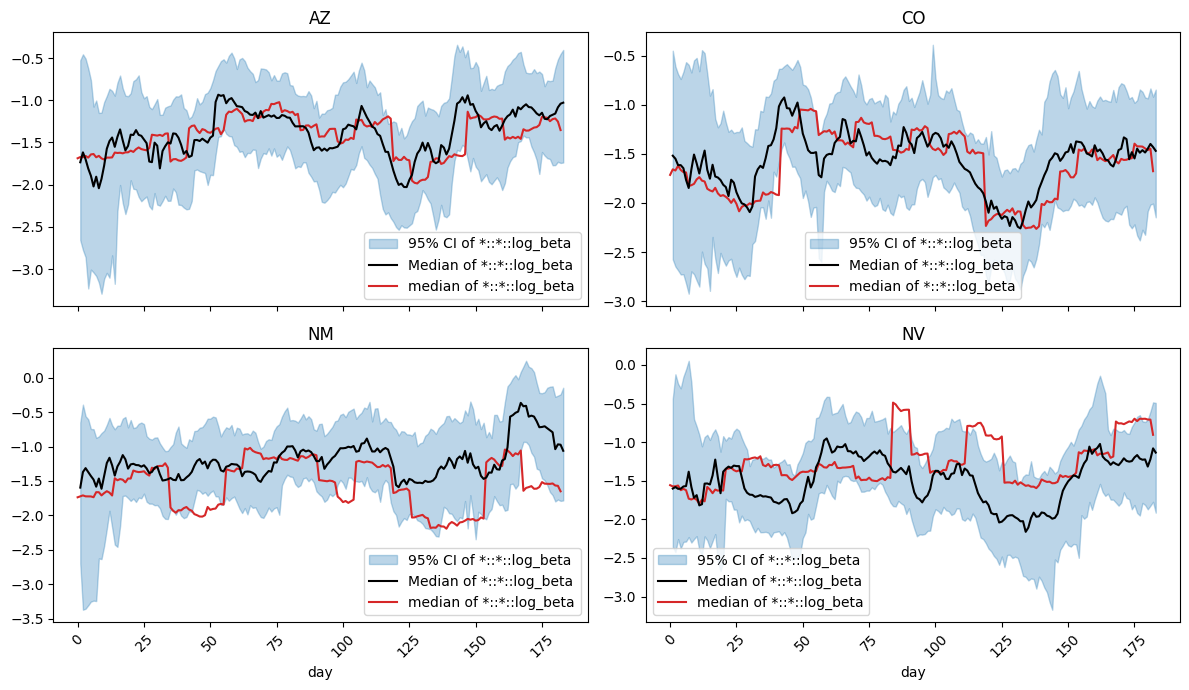

In [14]:
from epymorph.forecasting.pipeline import munge_pipeline_output

sim_date_range = np.arange(0, rume.time_frame.days, 1)
cols = 2
rows = ceil(n / cols)

plotter_daily = PlotRendererPipeline(particle_filter_output_daily)
geo = rume.scope.select.all()
time = rume.time_frame.select.all()

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.5 * rows), sharex=True)
axes = axes.flatten()

quantity = particle_filter_output_daily.param_select.by_name("log_beta")
plotter_daily.quantiles_plt(
    axes,
    geo,
    time,
    quantity,
    line_kwargs=[{"color": "black"}],
    fill_kwargs=[{"color": "tab:blue", "alpha": 0.3}],
    credible_intervals=[95],
    legend="on",
)

quantity = particle_filter_output.param_select.by_name("log_beta")
realization = particle_filter_output.select.all().agg(["median"])
line = munge_pipeline_output(particle_filter_output, realization, geo, time, quantity)

beta_label = "*::*::log_beta"
for ax, node in zip(axes, rume.scope.node_ids):
    curr_line = line[line["geo"] == node]
    ax.plot(
        sim_date_range,
        curr_line[beta_label],
        color="tab:red",
        label=f"median of {beta_label}",
    )
    ax.legend()

fig.tight_layout()
plt.show()

![](img/G3-pf/fit_of_beta_daily.png)

We observe a $\beta$ which is qualitatively similar to the estimate from the weekly inference. However, the dynamics are more finely resolved and we reduce the stepping effect observed with the weekly estimate. 

- [ ] Finally, let's look at the inference of the observed states. We can also validate our model by comparing the dynamics of the $H$ compartment with the real counts from the CDC. 

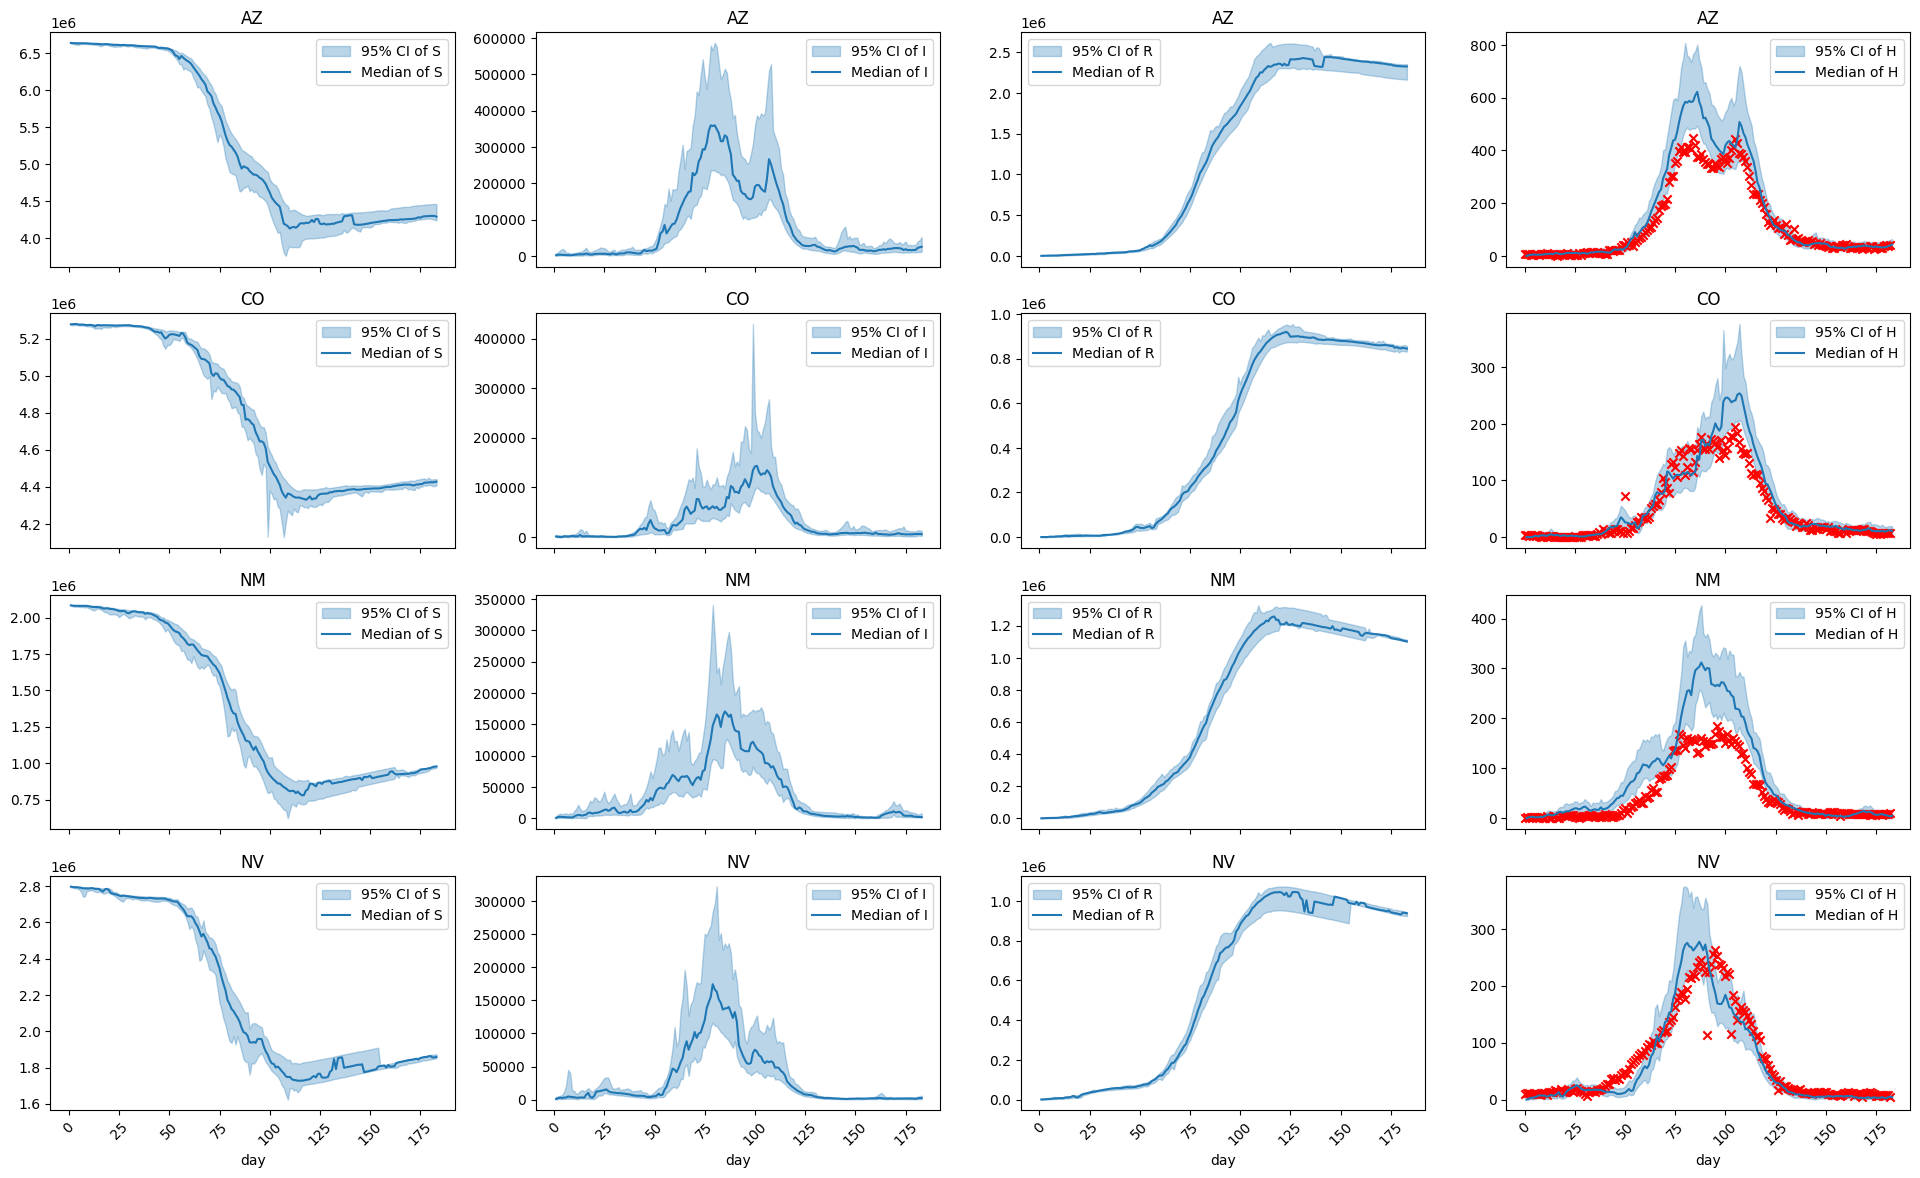

In [19]:
a = particle_filter_output.compartments.shape[3]
compartment_labels = ["S", "I", "R", "H"]
sim_date_range = np.arange(0, rume.time_frame.days, 1)

rows = n
cols = a

observations_daily_hosp = InfluenzaStateHospitalizationDaily(column="hospitalizations")

real_data_result_hosp = (
    observations_daily_hosp.with_context(scope=rume.scope, time_frame=rume.time_frame)
    .inspect()
    .result
)

real_data_hosp = real_data_result_hosp["value"]

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.5 * rows), sharex=True)

plotter = PlotRendererPipeline(particle_filter_output_daily)
geo = rume.scope.select.all()
time = rume.time_frame.select.all()

for col in range(cols):
    col_axes = axes[:, col]

    quantity = rume.ipm.select.compartments(compartment_labels[col])

    plotter.quantiles_plt(
        col_axes,
        geo,
        time,
        quantity,
        line_kwargs=[{"color": "tab:blue"}],
        fill_kwargs=[{"color": "tab:blue", "alpha": 0.3}],
        credible_intervals=[95],
        legend="on",
        time_format="day",
    )

    if compartment_labels[col] == "H":
        for i, ax in enumerate(col_axes):
            ax.scatter(
                sim_date_range,
                real_data_hosp[:, i],
                color="red",
                marker="x",
                label="Hospitalization data",
            )

plt.show()

![](img/G3-pf/fit_of_compartments_daily.png)

The latent state estimation is vastly improved and the estimated trajectories are reasonable for the $H$ compartment. The algorithm is more able to account for model error at this daily data resolution. 